In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, backend as K
import numpy as np

# Set the seed for reproducibility
SEED = 42
tf.keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()

2025-08-17 21:27:47.280967: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-17 21:27:47.288417: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1755476867.296136   61394 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1755476867.298499   61394 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1755476867.304517   61394 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
gpus = tf.config.list_physical_devices('GPU')
print("GPU Available:", gpus)
print("cuDNN Enabled:", tf.test.is_built_with_cuda())

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# Set the number of intra-op and inter-op threads
NUM_CORES = 8
tf.config.threading.set_intra_op_parallelism_threads(NUM_CORES)
tf.config.threading.set_inter_op_parallelism_threads(NUM_CORES)

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
cuDNN Enabled: True


Training data shape: (60000, 28, 28, 1)
Test data shape: (10000, 28, 28, 1)


I0000 00:00:1755476868.801072   61394 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 21680 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:01:00.0, compute capability: 8.6



Data pipeline created successfully.


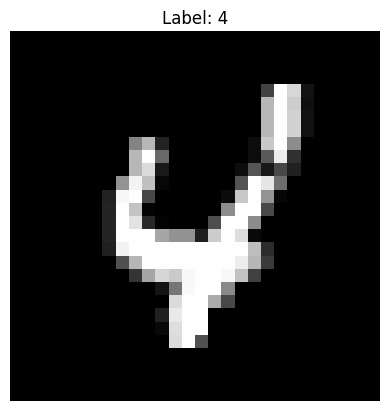

In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Load and Preprocess the MNIST Dataset (Keras version) ---

# Load the data directly using the Keras API. This returns NumPy arrays.
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize pixel values to [0, 1] and add a channel dimension.
# The original shape is (60000, 28, 28). We need (60000, 28, 28, 1).
x_train = np.expand_dims(x_train.astype('float32') / 255.0, axis=-1)
x_test = np.expand_dims(x_test.astype('float32') / 255.0, axis=-1)

print(f"Training data shape: {x_train.shape}")
print(f"Test data shape: {x_test.shape}")


# --- 2. Create TensorFlow Data Pipeline ---
batch_size = 128

# Create tf.data.Dataset objects for efficient training
train_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_dataset = train_dataset.shuffle(buffer_size=60000).batch(batch_size).prefetch(tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices((x_test, y_test))
test_dataset = test_dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)


# --- 3. Verify the Data ---
# This part remains useful for a quick sanity check.
print("\nData pipeline created successfully.")  
for images, labels in train_dataset.take(1):
  plt.imshow(images[0, :, :, 0], cmap='gray')
  plt.title(f'Label: {labels[0].numpy()}')
  plt.axis('off')
  plt.show()
  break # We only need to see one batch

In [4]:
from tensorflow.keras import layers, Model

# --- Dynamic Hyperparameters ---
# We get the image shape directly from the data we loaded in Step 1
image_shape = x_train.shape[1:]
latent_dim_a = 50
latent_dim_z = 50


# =============================================================
# Encoder 1: Auxiliary Inference Model q(a|x) - Class Version
# =============================================================
class Encoder_q_a_x(Model):
    """Maps an input image x to the parameters of the distribution for a."""
    def __init__(self, latent_dim, name='q_a_x_encoder', **kwargs):
        super().__init__(name=name, **kwargs)
        # Define the layers of the network
        self.conv1 = layers.Conv2D(32, 3, strides=2, padding='same')
        self.bn1 = layers.BatchNormalization() # NEW
        self.conv2 = layers.Conv2D(64, 3, strides=2, padding='same')
        self.bn2 = layers.BatchNormalization() # NEW
        self.conv3 = layers.Conv2D(128, 3, strides=1, padding='same')
        self.bn3 = layers.BatchNormalization() # NEW
        self.flatten = layers.Flatten()
        self.dense = layers.Dense(256)
        self.bn_dense = layers.BatchNormalization() # NEW
        self.leaky_relu = layers.LeakyReLU(alpha=0.2)
        self.mu_a_layer = layers.Dense(latent_dim, name='mu_a')
        self.log_var_a_layer = layers.Dense(latent_dim, name='log_var_a')

    def call(self, x):
        # Define the forward pass
        h = self.bn1(self.conv1(x))
        h = self.leaky_relu(h)
        h = self.bn2(self.conv2(h))
        h = self.leaky_relu(h)
        h = self.bn3(self.conv3(h))
        h = self.leaky_relu(h)
        h = self.flatten(h)
        h = self.bn_dense(self.dense(h))
        h = self.leaky_relu(h)
        mu_a = self.mu_a_layer(h)
        log_var_a = self.log_var_a_layer(h)
        return mu_a, log_var_a

# =============================================================
# Encoder 2: Latent Inference Model q(z|x, a) - Class Version
# =============================================================
class Encoder_q_z_xa(Model):
    """Maps an image x AND an auxiliary 'a' to the parameters for z."""
    def __init__(self, latent_dim, name='q_z_xa_encoder', **kwargs):
        super().__init__(name=name, **kwargs)
        # Define layers for processing the image 'x'
        self.conv1 = layers.Conv2D(32, 3, strides=2, padding='same')
        self.bn1 = layers.BatchNormalization() # NEW
        self.conv2 = layers.Conv2D(64, 3, strides=2, padding='same')
        self.bn2 = layers.BatchNormalization() # NEW
        self.conv3 = layers.Conv2D(128, 3, strides=1, padding='same')
        self.bn3 = layers.BatchNormalization() # NEW

        self.flatten = layers.Flatten()
        # Define layers for the combined path
        self.dense1 = layers.Dense(256)
        self.bn_dense = layers.BatchNormalization() # NEW
        self.leaky_relu = layers.LeakyReLU(alpha=0.2)  

        self.mu_z_layer = layers.Dense(latent_dim, name='mu_z')
        self.log_var_z_layer = layers.Dense(latent_dim, name='log_var_z')

    def call(self, inputs):
        # The 'inputs' will be a list: [image_x, variable_a]
        x, a = inputs
        # Process 'x' through its layers
        h_x = self.bn1(self.conv1(x))
        h_x = self.leaky_relu(h_x)
        h_x = self.bn2(self.conv2(h_x))
        h_x = self.leaky_relu(h_x)
        h_x = self.bn3(self.conv3(h_x))
        h_x = self.leaky_relu(h_x)
        h_x = self.flatten(h_x)        
        # Concatenate the processed image features with the input 'a'
        h_concat = layers.concatenate([h_x, a])
        # Run the combined features through the final layers
        h = self.bn_dense(self.dense1(h_concat))
        h = self.leaky_relu(h)
        mu_z = self.mu_z_layer(h)
        log_var_z = self.log_var_z_layer(h)
        return mu_z, log_var_z

# --- Instantiate and Build the Encoders ---
q_a_x_model = Encoder_q_a_x(latent_dim=latent_dim_a)
q_z_xa_model = Encoder_q_z_xa(latent_dim=latent_dim_z)

# To print the summary, we need to "build" the models by passing a sample input.
# This lets Keras know the input shape and connect all the layers.
dummy_x = tf.zeros((batch_size, *image_shape))
dummy_a = tf.zeros((batch_size, latent_dim_a))

# Calling the models on dummy data to build them
_ = q_a_x_model(dummy_x)
_ = q_z_xa_model([dummy_x, dummy_a])

print("--- Encoder q(a|x) Summary ---")
q_a_x_model.summary()

print("\n--- Encoder q(z|x, a) Summary ---")
q_z_xa_model.summary()

/home/nicolas/Documentos/UTN/INA/giar_ina_dev/.venv/lib/python3.12/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


--- Encoder q(a|x) Summary ---


I0000 00:00:1755476869.710082   61394 cuda_dnn.cc:529] Loaded cuDNN version 90701


Model: "q_a_x_encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (128, 14, 14, 32)      │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (128, 14, 14, 32)      │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (128, 7, 7, 64)        │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (128, 7, 7, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (128, 7, 7, 128)       │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (128, 7, 7, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (128, 6272)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (128, 256)             │     1,605,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (128, 256)             │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mu_a (Dense)                    │ (128, 50)              │        12,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ log_var_a (Dense)               │ (128, 50)              │        12,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

...

Model: "q_z_xa_encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (128, 14, 14, 32)      │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (128, 14, 14, 32)      │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (128, 7, 7, 64)        │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (128, 7, 7, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (128, 7, 7, 128)       │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (128, 7, 7, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (128, 6272)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (128, 256)             │     1,618,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (128, 256)             │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mu_z (Dense)                    │ (128, 50)              │        12,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ log_var_z (Dense)               │ (128, 50)              │        12,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,738,980 (6.63 MB)

 Trainable params: 1,738,020 (6.63 MB)

 Non-trainable params: 960 (3.75 KB)

In [5]:
from tensorflow.keras import layers, Model

# =============================================================
# Decoder 1: Main Generative Model p(x|z) - Class Version
# =============================================================
class Decoder_p_x_z(Model):
    """Generates an image x from a latent variable z."""
    def __init__(self, image_shape, name='p_x_z_decoder', **kwargs):
        super().__init__(name=name, **kwargs)
        # We start by projecting and reshaping the latent z
        # The target shape is the shape of the output of the last conv layer in the encoder
        self.dense = layers.Dense(7 * 7 * 128)
        self.bn_dense = layers.BatchNormalization() # NEW
        self.reshape = layers.Reshape((7, 7, 128))
        
        # Then we use transposed convolutions to upsample back to the image shape
        self.conv_transpose1 = layers.Conv2DTranspose(128, 3, strides=1, padding='same')
        self.bn1 = layers.BatchNormalization() # NEW
        self.conv_transpose2 = layers.Conv2DTranspose(64, 3, strides=2, padding='same')
        self.bn2 = layers.BatchNormalization() # NEW
        self.conv_transpose3 = layers.Conv2DTranspose(32, 3, strides=2, padding='same')
        self.bn3 = layers.BatchNormalization() # NEW

        self.leaky_relu = layers.LeakyReLU(alpha=0.2)
        # It has 1 filter (for grayscale) and a sigmoid activation for pixel values [0, 1]
        self.conv_transpose_out = layers.Conv2DTranspose(image_shape[-1], 3, strides=1, padding='same', activation='sigmoid')


    def call(self, z):
        h = self.bn_dense(self.dense(z))
        h = self.leaky_relu(h)
        h = self.reshape(h)
        h = self.bn1(self.conv_transpose1(h))
        h = self.leaky_relu(h)
        h = self.bn2(self.conv_transpose2(h))
        h = self.leaky_relu(h)
        h = self.bn3(self.conv_transpose3(h))
        h = self.leaky_relu(h)
        x_reconstructed = self.conv_transpose_out(h)
        return x_reconstructed

# =============================================================
# Decoder 2: Auxiliary Generative Model p(a|z,x) - Class Version
# =============================================================
class Decoder_p_a_zx(Model):
    """Predicts parameters for 'a' from a latent 'z' and an image 'x'."""
    def __init__(self, latent_dim, name='p_a_zx_decoder', **kwargs):
        super().__init__(name=name, **kwargs)
        self.flatten = layers.Flatten()
        self.dense1 = layers.Dense(256)
        self.bn1 = layers.BatchNormalization() # NEW
        self.dense2 = layers.Dense(256)
        self.bn2 = layers.BatchNormalization() # NEW
        self.dense3 = layers.Dense(256)
        self.bn3 = layers.BatchNormalization() # NEW
        self.leaky_relu = layers.LeakyReLU(alpha=0.2) # NEW ACTIVATION

        # This decoder also outputs a distribution's parameters
        self.mu_a_pred_layer = layers.Dense(latent_dim, name='mu_a_pred')
        self.log_var_a_pred_layer = layers.Dense(latent_dim, name='log_var_a_pred')

    def call(self, inputs):
        z, x = inputs
        # We flatten the image x to combine it with z
        x_flat = self.flatten(x)
        # Concatenate and pass through dense layers
        h_concat = layers.concatenate([z, x_flat])

        h = self.bn1(self.dense1(h_concat))
        h = self.leaky_relu(h)
        h = self.bn2(self.dense2(h))
        h = self.leaky_relu(h)
        h = self.bn3(self.dense3(h))
        h = self.leaky_relu(h)
        
        mu_a_pred = self.mu_a_pred_layer(h)
        log_var_a_pred = self.log_var_a_pred_layer(h)
        return mu_a_pred, log_var_a_pred

# --- Instantiate and Build the Decoders ---
p_x_z_model = Decoder_p_x_z(image_shape)
p_a_zx_model = Decoder_p_a_zx(latent_dim=latent_dim_a)

# Build the models by passing sample inputs
dummy_z = tf.zeros((batch_size, latent_dim_z))
# The dummy_x for the p_a_zx_model is the original image, not flattened yet
dummy_x = tf.zeros((batch_size, *image_shape))

_ = p_x_z_model(dummy_z)
_ = p_a_zx_model([dummy_z, dummy_x])

print("--- Decoder p(x|z) Summary ---")
p_x_z_model.summary()

print("\n--- Decoder p(a|z,x) Summary ---")
p_a_zx_model.summary()

--- Decoder p(x|z) Summary ---


Model: "p_x_z_decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (128, 6272)            │       319,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (128, 6272)            │        25,088 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (128, 7, 7, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (128, 7, 7, 128)       │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (128, 7, 7, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (128, 14, 14, 64)      │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (128, 14, 14, 64)      │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (128, 28, 28, 32)      │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (128, 28, 28, 32)      │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (128, 28, 28, 1)       │           289 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 585,985 (2.24 MB)

 Trainable params: 572,993 (2.19 MB)

...

Model: "p_a_zx_decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (128, 784)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (128, 256)             │       213,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (128, 256)             │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (128, 256)             │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (128, 256)             │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (128, 256)             │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (128, 256)             │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mu_a_pred (Dense)               │ (128, 50)              │        12,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ log_var_a_pred (Dense)          │ (128, 50)              │        12,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 374,116 (1.43 MB)

 Trainable params: 372,580 (1.42 MB)

 Non-trainable params: 1,536 (6.00 KB)

In [6]:
from tensorflow.keras import layers, Model

# =============================================================
# Reparameterization Trick as a Layer
# =============================================================
class Sampling(layers.Layer):
    """
    Uses (mu, log_var) to sample z, the latent vector.
    This is the reparameterization trick.
    """
    def call(self, inputs):
        mu, log_var = inputs
        batch = tf.shape(mu)[0]
        dim = tf.shape(mu)[1]
        # Sample random noise from a standard normal distribution
        epsilon = tf.keras.backend.random_normal(shape=(batch, dim))
        # Compute the sample z = mu + sigma * epsilon
        # Note: sigma = exp(0.5 * log_var)
        return mu + tf.exp(0.5 * log_var) * epsilon

### The Loss Function

In [7]:
def adgm_loss_fn(y_true, y_pred):
    """
    Calculates the ADGM loss as the negative of the Evidence Lower Bound (ELBO).
    """
    # 1. Reconstruction loss for the image x (log p(x|z))
    # We use binary cross-entropy, which is equivalent to the log-probability
    # for a Bernoulli distribution over the pixels.
    recon_loss_x = tf.reduce_mean(tf.reduce_sum(
        tf.keras.losses.binary_crossentropy(y_true, y_pred['x_reconstructed']),
        axis=[1, 2]
    ))


    # 2. KL divergence for z (KL[q(z|x,a) || p(z)])
    # This measures how much q(z|x,a) deviates from a standard normal distribution.
    kl_loss_z = tf.reduce_mean(-0.5 * tf.reduce_sum(
        1 + y_pred['log_var_z'] - tf.square(y_pred['mu_z']) - tf.exp(y_pred['log_var_z']),
        axis=1
    ))

    # 3. KL divergence for a (KL[q(a|x) || p(a)])
    # This measures how much q(a|x) deviates from a standard normal distribution.
    kl_loss_a = tf.reduce_mean(-0.5 * tf.reduce_sum(
        1 + y_pred['log_var_a'] - tf.square(y_pred['mu_a']) - tf.exp(y_pred['log_var_a']),
        axis=1
    ))
    
    # 4. Reconstruction loss for a (-log p(a|z,x))
    # This is the negative log-probability of the sampled 'a' under the
    # distribution predicted by the auxiliary decoder.
    log_p_a_zx = -0.5 * tf.reduce_sum(
        tf.square(y_pred['a_sampled'] - y_pred['mu_a_pred']) / tf.exp(y_pred['log_var_a_pred']) + \
        y_pred['log_var_a_pred'] + tf.math.log(2. * np.pi),
        axis=1
    )

    recon_loss_a = tf.reduce_mean(-log_p_a_zx)
    
    total_loss = recon_loss_x + recon_loss_a + kl_loss_z + kl_loss_a

    # The total loss is the sum of these components (which is -ELBO)
    # We take the mean over the batch.
    total_loss = tf.reduce_mean(recon_loss_x + recon_loss_a + kl_loss_z + kl_loss_a)
    
    return {
        "loss": total_loss,
        "recon_loss_x": recon_loss_x,
        "recon_loss_a": recon_loss_a,
        "kl_loss_z": kl_loss_z,
        "kl_loss_a": kl_loss_a,
    }

### The model

In [8]:
from tensorflow.keras import layers, Model

# =============================================================
# The Full ADGM Model
# =============================================================
class ADGM(Model):
    """
    The complete Auxiliary Deep Generative Model.
    This class orchestrates the encoders, sampling, and decoders.
    """
    def __init__(self, image_shape, latent_dim_a, latent_dim_z, name='ADGM', **kwargs):
        super().__init__(name=name, **kwargs)
        # Instantiate all the component models
        self.q_a_x_model = Encoder_q_a_x(latent_dim=latent_dim_a)
        self.q_z_xa_model = Encoder_q_z_xa(latent_dim=latent_dim_z)
        self.p_x_z_model = Decoder_p_x_z(image_shape=image_shape)
        self.p_a_zx_model = Decoder_p_a_zx(latent_dim=latent_dim_a)
        self.sampling_layer = Sampling()

    def call(self, x):
        # === INFERENCE (Recognition) PATH ===
        # q(a|x) -> sample a
        mu_a, log_var_a = self.q_a_x_model(x)
        a = self.sampling_layer([mu_a, log_var_a])

        # q(z|x, a) -> sample z
        mu_z, log_var_z = self.q_z_xa_model([x, a])
        z = self.sampling_layer([mu_z, log_var_z])

        # === GENERATIVE PATH ===
        # p(x|z) -> reconstruct x
        x_reconstructed = self.p_x_z_model(z)

        # p(a|z, x) -> predict a's parameters
        mu_a_pred, log_var_a_pred = self.p_a_zx_model([z, x])
        
        # Return everything needed for the loss function
        return {
            "mu_a": mu_a, "log_var_a": log_var_a,
            "mu_z": mu_z, "log_var_z": log_var_z,
            "x_reconstructed": x_reconstructed,
            "mu_a_pred": mu_a_pred, "log_var_a_pred": log_var_a_pred,
            "a_sampled": a 
        }
    
    def train_step(self, data):
        images, _ = data
        
        with tf.GradientTape() as tape:
            model_outputs = self(images, training=True)
            # The loss function now returns a dictionary of metrics
            losses = adgm_loss_fn(images, model_outputs)
            total_loss = losses["loss"] # The main loss to optimize
            
        grads = tape.gradient(total_loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))
        
        # Return the dictionary of losses for Keras to track and display
        return losses

# --- Instantiate the Full Model ---
adgm_model = ADGM(image_shape, latent_dim_a, latent_dim_z)

# Test it on one batch of data to see the output structure
for images, _ in train_dataset.take(1):
    outputs = adgm_model(images)
    print("--- Full ADGM Model instantiated ---")
    print("Model outputs:")
    for key, value in outputs.items():
        print(f"  - {key}: shape {value.shape}")

--- Full ADGM Model instantiated ---
Model outputs:
  - mu_a: shape (128, 50)
  - log_var_a: shape (128, 50)
  - mu_z: shape (128, 50)
  - log_var_z: shape (128, 50)
  - x_reconstructed: shape (128, 28, 28, 1)
  - mu_a_pred: shape (128, 50)
  - log_var_a_pred: shape (128, 50)
  - a_sampled: shape (128, 50)


2025-08-17 21:27:50.334037: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


### Compiling and Training the Model

In [9]:
# --- 1. Instantiate Model and Compile ---
epochs = 20
learning_rate = 1e-4

adgm_model = ADGM(image_shape, latent_dim_a, latent_dim_z)
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

# We compile the model with just the optimizer. The loss calculation is
# now handled inside the model's train_step.
adgm_model.compile(optimizer=optimizer)


# --- 2. Fit the Model ---
print("🚀 Starting training with model.fit()...")

# You can now easily add callbacks!
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='loss', patience=5, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='loss', patience=5, verbose=1, factor=0.5, min_lr=1e-6),
]

history = adgm_model.fit(
    train_dataset,
    epochs=epochs,
    callbacks=callbacks
)

print("✅ Training finished!")

🚀 Starting training with model.fit()...
Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - kl_loss_a: 8.2332 - kl_loss_z: 22.3556 - loss: 353.3499 - recon_loss_a: 73.2115 - recon_loss_x: 249.5497 - learning_rate: 1.0000e-04
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - kl_loss_a: 12.6367 - kl_loss_z: 26.8452 - loss: 197.0441 - recon_loss_a: 46.5535 - recon_loss_x: 111.0088 - learning_rate: 1.0000e-04
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - kl_loss_a: 21.0511 - kl_loss_z: 28.2884 - loss: 176.7441 - recon_loss_a: 33.1909 - recon_loss_x: 94.2136 - learning_rate: 1.0000e-04
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - kl_loss_a: 28.5167 - kl_loss_z: 28.4085 - loss: 168.4855 - recon_loss_a: 23.4126 - recon_loss_x: 88.1478 - learning_rate: 1.0000e-04
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - kl_loss_a: 34.4731 - kl_loss_z: 28.3768 - loss: 163.9894 - recon_loss_a: 16.1610 - recon_loss_x: 84.9785 - learning_rate: 1.0000e-04
Epoch 6/20
469/469

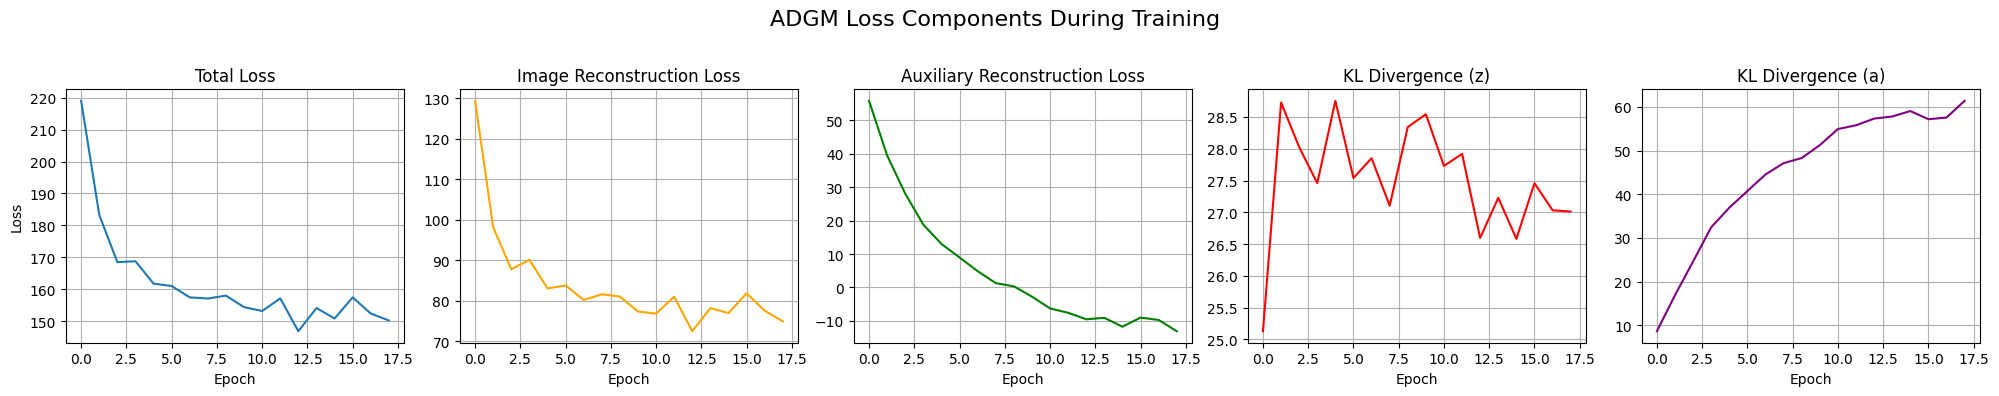

In [10]:
import pandas as pd

# Create a DataFrame from the history object for easier plotting
history_df = pd.DataFrame(history.history)

# Create a horizontal plot with 5 subplots (1 for each loss component + total loss)
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle('ADGM Loss Components During Training', fontsize=16)

# Plot 1: Total Loss
axes[0].plot(history_df['loss'], label='Total Loss')
axes[0].set_title('Total Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True)

# Plot 2: Reconstruction Loss (x)
axes[1].plot(history_df['recon_loss_x'], label='Reconstruction Loss (x)', color='orange')
axes[1].set_title('Image Reconstruction Loss')
axes[1].set_xlabel('Epoch')
axes[1].grid(True)

# Plot 3: Reconstruction Loss (a)
axes[2].plot(history_df['recon_loss_a'], label='Reconstruction Loss (a)', color='green')
axes[2].set_title('Auxiliary Reconstruction Loss')
axes[2].set_xlabel('Epoch')
axes[2].grid(True)

# Plot 4: KL Divergence (z)
axes[3].plot(history_df['kl_loss_z'], label='KL Loss (z)', color='red')
axes[3].set_title('KL Divergence (z)')
axes[3].set_xlabel('Epoch')
axes[3].grid(True)

# Plot 5: KL Divergence (a)
axes[4].plot(history_df['kl_loss_a'], label='KL Loss (a)', color='purple')
axes[4].set_title('KL Divergence (a)')
axes[4].set_xlabel('Epoch')
axes[4].grid(True)

plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust layout to make room for the suptitle
plt.show()

### Latent space plot

Generating latent space representations for the test set...


2025-08-17 21:29:42.829142: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Generated 10000 latent vectors of dimension 50.
Applying t-SNE to reduce dimensionality to 2D... (this may take a minute)
t-SNE finished.


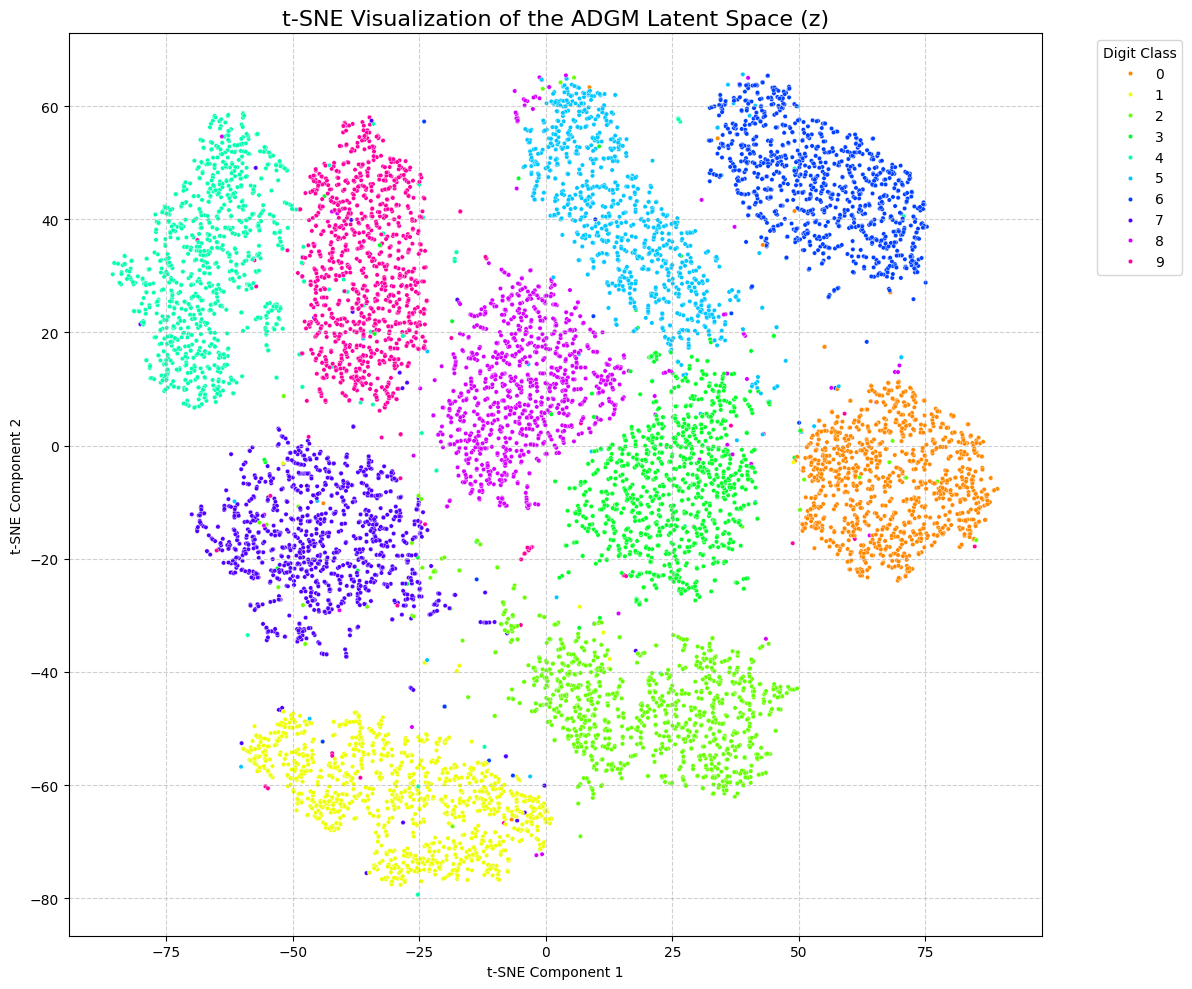

In [11]:
from sklearn.manifold import TSNE
import seaborn as sns

# --- 1. Get Latent Representations from the Test Set ---
print("Generating latent space representations for the test set...")

# We'll store the latent means (mu_z) and their corresponding labels here
all_mu_z = []
all_labels = []

# Iterate through the entire test dataset
for images, labels in test_dataset:
    # Get the outputs from the inference path
    mu_a, log_var_a = adgm_model.q_a_x_model(images)
    # We use mu_a as a stable representation for 'a'
    mu_z, log_var_z = adgm_model.q_z_xa_model([images, mu_a])
    
    all_mu_z.append(mu_z.numpy())
    all_labels.append(labels.numpy())

# Concatenate all batches into single NumPy arrays
all_mu_z = np.concatenate(all_mu_z, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

print(f"Generated {all_mu_z.shape[0]} latent vectors of dimension {all_mu_z.shape[1]}.")


# --- 2. Apply t-SNE ---
print("Applying t-SNE to reduce dimensionality to 2D... (this may take a minute)")

tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42)
latent_space_2d = tsne.fit_transform(all_mu_z)

print("t-SNE finished.")


# --- 3. Plot the 2D Latent Space ---

plt.figure(figsize=(12, 10))

# Dynamically determine the number of classes and create a color palette
num_classes = len(np.unique(all_labels))
palette = sns.color_palette("hsv", num_classes)

# Create the scatter plot
scatter = sns.scatterplot(
    x=latent_space_2d[:, 0],
    y=latent_space_2d[:, 1],
    hue=all_labels,
    palette=palette,
    legend='full',
    s=10 # Marker size
)

plt.title('t-SNE Visualization of the ADGM Latent Space (z)', fontsize=16)
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.legend(title='Digit Class', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Reconstruction plot

In [12]:
# def generate_and_plot_images(model, num_images_to_generate):
#     # Sample random points from the standard normal distribution (our prior p(z)).
#     random_latent_vectors = tf.random.normal(shape=(num_images_to_generate, model.q_z_xa_model.mu_z_layer.units))
    
#     # Use the generative decoder p(x|z) to generate images from these points.
#     generated_images = model.p_x_z_model(random_latent_vectors)
    
#     # Plot the results
#     plt.figure(figsize=(10, 10))
#     for i in range(num_images_to_generate):
#         plt.subplot(5, 5, i + 1)
#         plt.imshow(generated_images[i, :, :, 0], cmap='gray')
#         plt.axis('off')
#     plt.suptitle("Generated Digits from Latent Space", fontsize=16)
#     plt.show()

# # Generate 25 new images
# print("\nGenerating new images from the trained model...")
# generate_and_plot_images(adgm_model, 25)

Calculating latent space centroids for each digit...
Centroids calculated.


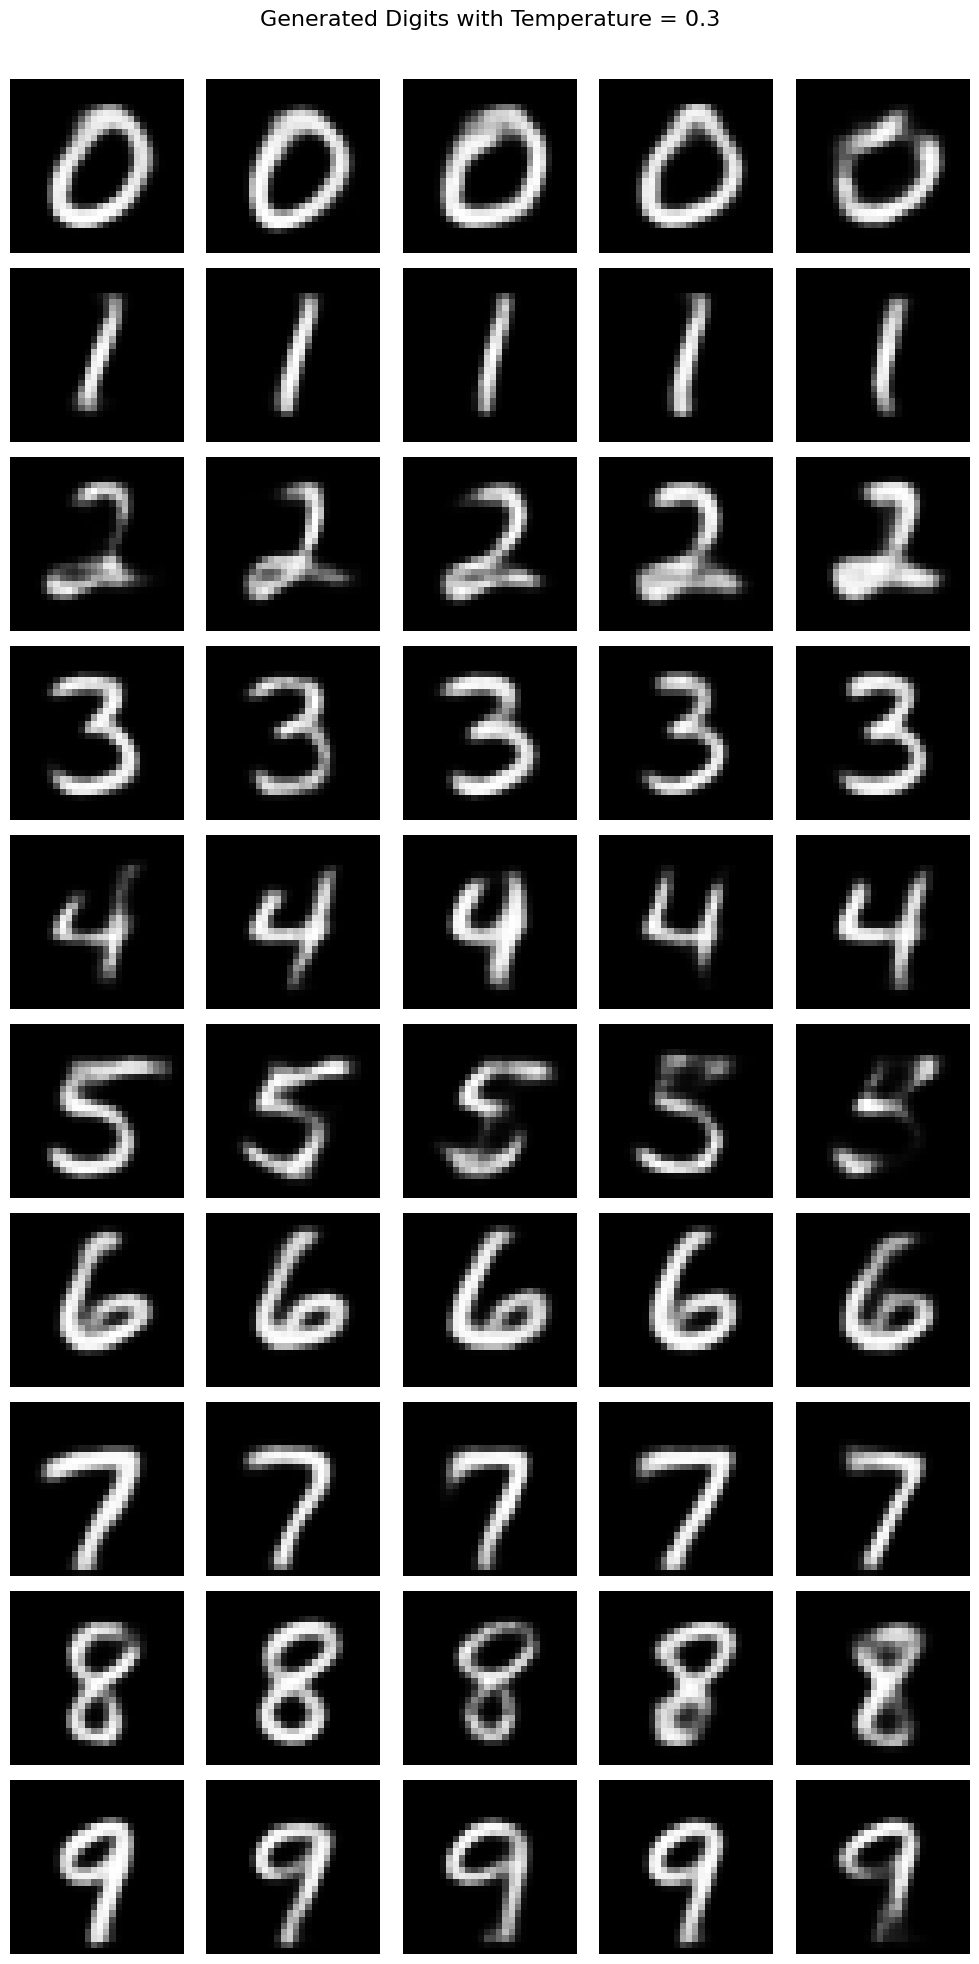

In [14]:
# --- 1. Calculate Latent Space Centroids for Each Class ---
# (This assumes you have already run the t-SNE code to get all_mu_z and all_labels)

print("Calculating latent space centroids for each digit...")
num_classes = len(np.unique(all_labels))
latent_dim = all_mu_z.shape[1]
class_centroids = {}

for i in range(num_classes):
    # Find all latent vectors for the current class
    class_mu_z = all_mu_z[all_labels == i]
    # Calculate the mean vector (centroid)
    class_centroids[i] = np.mean(class_mu_z, axis=0)

print("Centroids calculated.")


# --- 2. Generate and Plot Images with Temperature Control ---

# Adjust this value to control creativity.
# temperature = 0.0 -> Generates the exact average digit (no variation)
# temperature = 0.5 -> Low variation, very "clean" digits
# temperature = 1.0 -> Standard variation
# temperature = 1.5 -> High variation, more "creative" or distorted digits
temperature = 0.3
num_samples_per_class = 5

# Create the plot matrix
fig, axes = plt.subplots(num_classes, num_samples_per_class, figsize=(10, 20))
fig.suptitle(f'Generated Digits with Temperature = {temperature}', fontsize=16)

for i in range(num_classes):
    # Get the centroid for the current class
    centroid = class_centroids[i].reshape(1, latent_dim)
    
    # Set the y-label for the row to indicate the digit
    axes[i, 0].set_ylabel(f'Digit "{i}"', rotation=0, size='large', labelpad=40)
    
    for j in range(num_samples_per_class):
        # Generate random noise from a standard normal distribution
        epsilon = tf.random.normal(shape=(1, latent_dim))
        
        # Create a new sample by moving from the centroid according to the temperature
        z_sample = centroid + temperature * epsilon
        
        # Generate an image from this new latent point
        generated_image_tensor = adgm_model.p_x_z_model(z_sample)
        generated_image = generated_image_tensor.numpy().reshape(image_shape)
        
        # Plot the image
        ax = axes[i, j]
        ax.imshow(generated_image[:, :, 0], cmap='gray')
        ax.axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()